# Time-to-Dropout Survival Analysis of a Student Cohort

## Executive Summary

**Setting.** An institutional-research office at a four-year college wants to understand *when*, not just *whether*, students leave. A first-time cohort is tracked term by term from matriculation; some graduate, some drop out, and a few are still enrolled when the observation window closes. Because the outcome for still-enrolled students is unknown (right-censored), and because graduation removes a student from the at-risk pool without being a dropout, ordinary pass/fail regression throws away the timing information and biases any estimate that ignores censoring. The right tool is **time-to-event (survival) analysis**, where the event of interest is **dropout** and the clock is measured in academic terms enrolled.

**Business question.** Does a student's **first-term academic standing** (an early-alert flag) separate the dropout-timing trajectories of the cohort, and which student characteristics drive the dropout hazard after adjustment? Answers feed an early-alert system: students whose estimated dropout hazard is high should receive advising outreach in their first terms, when intervention is cheapest and most effective.

**Approach.** We simulate a 100-student cohort inline (no external data), then work through a standard survival workflow:

1. **PROC MEANS** profiles the predictors across the three observed outcomes (Graduated / Dropped / still Enrolled) to confirm the simulated signal behaves sensibly.
2. **PROC FREQ** cross-tabulates first-term academic standing against outcome with a chi-square test of association.
3. **PROC UNIVARIATE** reports robust percentiles of time-to-dropout by standing.
4. **PROC LIFETEST** estimates Kaplan-Meier dropout curves stratified by standing and runs **log-rank** and **Wilcoxon** tests of equality.
5. **PROC PHREG** fits a multivariable **Cox proportional-hazards** model for the dropout hazard, with a reference-coded `CLASS` effect, Efron tie handling, and risk-limit confidence intervals.

**What the data show.** Of the 100 simulated students, **49 dropped, 49 graduated, and 2 remained enrolled** at the 12-term cutoff. Students flagged for **academic warning** in their first term (first-term GPA below 2.5) drop out far faster than students in good standing: median time-to-dropout **3.8 terms vs 8.7 terms**, a separation the log-rank test confirms (chi-square = 10.73, *p* = 0.0011). The Cox model identifies first-term GPA (hazard ratio 0.21 per GPA point, *p* < 0.0001), high-school GPA (HR 0.45, *p* = 0.027), and first-generation status (HR 2.03, *p* = 0.031) as significant adjusted drivers of dropout, while Pell-grant status is not significant once GPA is controlled (HR 0.95, *p* = 0.85).

> *All figures are illustrative and generated from synthetic data; they are not real student records. The cohort is intentionally sized at 100 students so the example is fully self-contained and quick to reproduce.*

## Data Sources

All data is **synthetic**, generated inline in the first DATA step with `CALL STREAMINIT(20260611)` and the `RAND` function. No external files or network access. One row per simulated student.

**Dataset `enrollments`** (100 rows, one row per student)

| Variable | Type | Description | Generating distribution |
|----------|------|-------------|--------------------------|
| `student_id` | Num | Unique student key | sequence 1–100 |
| `first_gen` / `first_gen_lbl` | Num / Char | First-generation flag (0/1) and label | Bernoulli, ~42% |
| `pell` | Num | Pell-grant (financial-need) flag (0/1) | Bernoulli, ~42% |
| `program` | Char | STEM / BUS / HUM | categorical (~42% / 32% / 26%) |
| `hs_gpa` | Num | High-school GPA (1.8–4.0) | Normal(3.00, 0.42), clamped |
| `term1_gpa` | Num | First-term college GPA (0–4.0) | f(hs_gpa, program) + Normal noise |
| `standing` | Char | First-term academic standing | `term1_gpa < 2.5` → Academic warning, else Good standing |
| `time_terms` | Num | Terms enrolled until event or censoring | competing Weibull draws; capped at 12 |
| `dropped` | Num | Dropout event indicator (1 = dropped, 0 = censored) | derived |
| `outcome` | Char | Graduated / Dropped / Enrolled | derived from competing draws |

A latent linear predictor on the log scale links each student's **dropout rate** to first-term GPA, high-school GPA, first-generation status, and financial need, so the predictors carry genuine but noisy signal. Dropout and graduation are drawn as **competing** latent times (Weibull); whichever occurs first inside a 12-term window becomes the observed outcome, and students who reach term 12 without either are right-censored. For the survival models the **event is dropout** (`dropped = 1`); graduation and ongoing enrollment are both treated as censoring (`dropped = 0`).

## 1. Simulate the student cohort

The first cell builds a synthetic cohort of 100 students. A latent linear predictor on the log scale ties each student's dropout rate to first-term GPA, high-school GPA, first-generation status, and Pell status. Dropout and graduation are generated as **competing** latent times (Weibull draws); whichever happens first inside a 12-term observation window becomes the observed outcome, and students who reach term 12 without dropping or graduating are right-censored. A first-term GPA below 2.5 flags the student for **academic warning** — the early-alert signal we test in the survival step. Random draws use `CALL STREAMINIT` for reproducibility and the `RAND` function across Uniform, Normal, and Weibull distributions. Hard floors and clamps keep every value plausible (GPAs in 0–4.0).

In [1]:
data enrollments;
    call streaminit(20260611);
    length standing $16 first_gen_lbl $16 program $4 outcome $12;
    do student_id = 1 to 100;
        /* First-generation and financial-need flags */
        first_gen = (rand("uniform") < 0.42);
        if first_gen then first_gen_lbl = "First-generation";
        else              first_gen_lbl = "Continuing-gen";
        pell = (rand("uniform") < 0.42);

        /* Program of study */
        v = rand("uniform");
        if      v < 0.42 then program = "STEM";
        else if v < 0.74 then program = "BUS";
        else                  program = "HUM";

        /* Academic preparation and first-term performance */
        hs_gpa = round(min(4.0, max(1.8, rand("normal", 3.00, 0.42))), 0.01);
        term1_gpa = round(min(4.0, max(0.0,
                     0.55*hs_gpa + 1.05 + 0.12*(program="STEM")
                     + rand("normal", 0, 0.42))), 0.01);

        /* Early-alert flag: first-term GPA below 2.5 = academic warning */
        if term1_gpa < 2.5 then standing = "Academic warning";
        else                    standing = "Good standing";

        /* Latent dropout hazard on the log scale: lower GPA, first-gen,
           and Pell status raise the dropout rate. */
        eta = -1.05
             - 1.45*(term1_gpa - 2.8)
             - 0.55*(hs_gpa - 3.0)
             + 1.05*first_gen
             + 0.45*pell;
        drop_rate = exp(eta);

        /* Competing latent times (terms): dropout vs graduation */
        t_drop = rand("weibull", 1.2, 7.0) / max(0.30, drop_rate);
        t_grad = rand("weibull", 2.0, 7.5)
                 * exp(-0.18*(term1_gpa - 2.8));

        /* 12-term administrative censoring window */
        censor_at = 12;
        if t_drop <= t_grad and t_drop <= censor_at then do;
            outcome = "Dropped";   dropped = 1; time_terms = t_drop;
        end;
        else if t_grad < t_drop and t_grad <= censor_at then do;
            outcome = "Graduated"; dropped = 0; time_terms = t_grad;
        end;
        else do;
            outcome = "Enrolled";  dropped = 0; time_terms = censor_at;
        end;
        time_terms = round(time_terms, 0.1);
        output;
    end;
    keep student_id first_gen first_gen_lbl pell program hs_gpa
         term1_gpa standing time_terms dropped outcome;
run;

NOTE: DATA enrollments


NOTE: Wrote enrollments (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## 2. Profile predictors by observed outcome

Before modeling, we confirm the simulated predictors move in the expected directions. **PROC MEANS** reports the count, mean, spread, and range of each numeric predictor within the three observed outcomes.

The cohort splits **49 Graduated / 49 Dropped / 2 still Enrolled**. Graduates carry a higher first-term GPA (mean **2.94** vs **2.54** for students who dropped) and a higher high-school GPA (**3.10** vs **2.90**) — exactly the academic-preparation gradient the analysis expects. The two still-enrolled students sit exactly at the 12-term censoring ceiling on `time_terms` (mean 12.00, standard deviation 0), the right-censoring an attrition analysis must respect. Among students who dropped, the event arrives early: mean **3.31 terms**, ranging from 0.1 to 8.9.

In [2]:
proc means data=enrollments n mean std min max maxdec=2;
    class outcome;
    var hs_gpa term1_gpa time_terms;
run;

                                                  The MEANS Procedure

                                               Analysis Variable : hs_gpa

        outcome            N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------
        Dropped               49           2.90           0.45           2.01           3.89
        Enrolled               2           3.10           0.17           2.98           3.22
        Graduated             49           3.10           0.46           1.97           4.00
        ------------------------------------------------------------------------------------

                                             Analysis Variable : term1_gpa

        outcome            N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------
        Dropped               49 

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Does the early-alert flag track the outcome?

The early-alert system flags any student whose first-term GPA falls below 2.5 for **academic warning**. **PROC FREQ** cross-tabulates that flag against the observed outcome and runs a chi-square test of association. We suppress row, column, and overall percentages (`NOROW NOCOL NOPERCENT`) so the table shows the raw counts, and add one-way frequencies of `standing` and first-generation status for the cohort composition.

The cross-tab is stark: of the **29** students flagged for academic warning, **21 dropped** and only 8 graduated; of the **71** in good standing, **41 graduated** and 28 dropped. The association is significant (chi-square = 9.21, df = 2, *p* = 0.0100; Cramer's V = 0.30). Note the **warning printed with it**: with 100 students and a thin two-graduate "Enrolled" column, a third of the table cells have expected counts below 5, so the chi-square *p*-value is fragile here. That fragility is exactly why the survival tests in the next sections — which use the full timing information rather than a 3×2 table — are the more trustworthy test of the standing effect.

                                                   The FREQ Procedure

Table of standing by outcome

standing         |   Dropped |  Enrolled | Graduated |      Total
-----------------+-----------+-----------+-----------+-----------
Academic warning |        21 |         0 |         8 |         29
-----------------+-----------+-----------+-----------+-----------
Good standing    |        28 |         2 |        41 |         71
-----------------+-----------+-----------+-----------+-----------
Total            |        49 |         2 |        49 |        100

Statistics for Table of standing by outcome

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                2 9.2089       0.0100
Likelihood Ratio Chi-Square               2 9.8909       0.0071

Cramer's V                           0.3035
Contingency Coefficient              0.2904


                                             

NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_standing_outcome.spec.json
NOTE: ODS plot written: freq_standing.spec.json
NOTE: ODS plot written: freq_first_gen_lbl.spec.json
NOTE: PROC FREQ statement used.


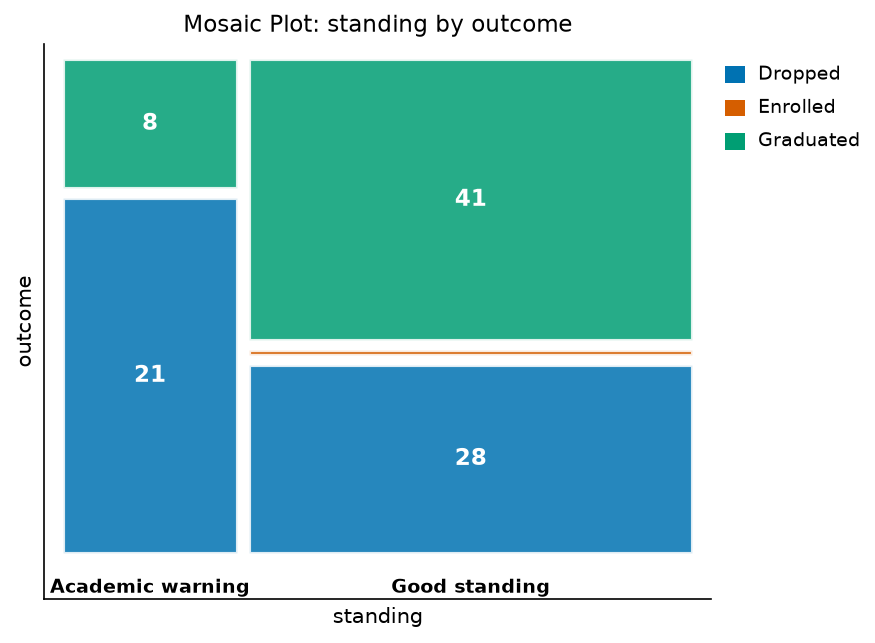

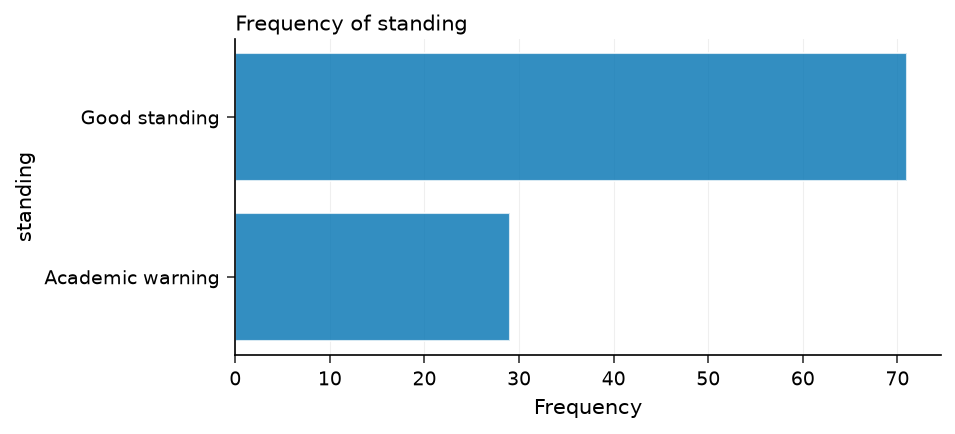

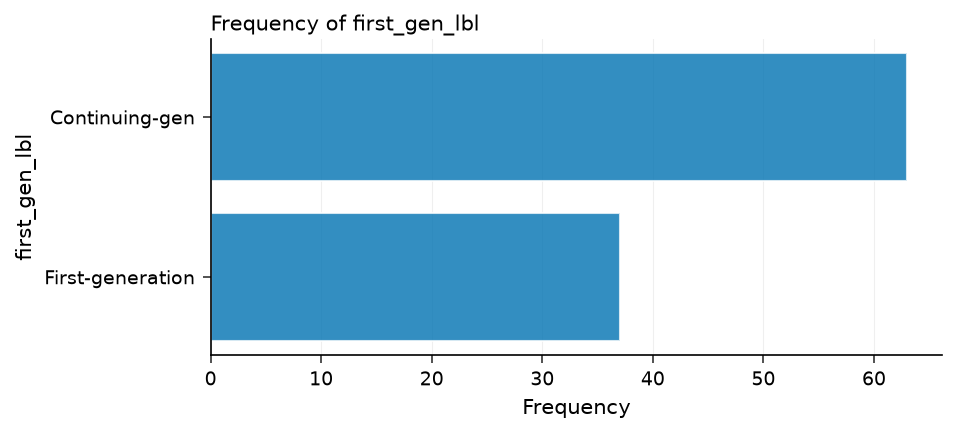

In [3]:
proc freq data=enrollments;
    tables standing*outcome / chisq norow nocol nopercent;
    tables standing first_gen_lbl;
run;

## 4. When do dropouts happen? Percentiles by standing

For the students who actually dropped, *when* did they leave? **PROC UNIVARIATE** (restricted to `dropped = 1`) reports the 10th, 50th (median), and 90th percentiles of time-to-dropout within each standing group, written to an output dataset that we then print. This describes the spread of dropout timing without assuming a distribution.

The median dropout among students who left occurs around term **2.4** (academic warning) versus **2.6** (good standing) — close, because *conditional on dropping*, both groups tend to leave early. The standing effect is therefore not mainly about *when* a dropout happens but about *how many* students drop and how quickly the at-risk pool thins, which is precisely what the Kaplan-Meier curves in the next section capture.

In [4]:
proc univariate data=enrollments noprint;
    where dropped = 1;
    class standing;
    var time_terms;
    output out=drop_ref pctlpts=10 50 90 pctlpre=t_ p=;
run;

proc print data=drop_ref noobs label;
    title "Time-to-dropout percentiles (terms), by academic standing";
run;
title;

                               Time-to-dropout percentiles (terms), by academic standing                                

        STANDING  T_10  T_50  T_90
Academic warning   0.2   2.4   7.9
Good standing      0.4   2.6   8.7



NOTE: PROC UNIVARIATE
NOTE: Output dataset drop_ref has 2 observations and 4 variables.
NOTE: PROC PRINT data=drop_ref

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


## 5. Kaplan-Meier dropout curves by academic standing

Now the core survival step. **PROC LIFETEST** estimates the nonparametric **Kaplan-Meier** survivor function for *time to dropout*, treating graduation and ongoing enrollment as censoring (`dropped(0)` marks the censored observations). Stratifying by `standing` produces one dropout curve per group, and `TEST=(LOGRANK WILCOXON)` runs two complementary tests of whether those curves differ: the **log-rank** test weights all event times equally (sensitive to late differences), while the **Wilcoxon** test up-weights early event times (sensitive to early attrition). `PLOTS=SURVIVAL` requests the overlaid survivor-curve graphic.

Across the cohort there are **49 dropout events and 51 censored** observations. The curves separate clearly: students on academic warning reach **median survival (time-to-dropout) of 3.8 terms**, while good-standing students last more than twice as long (**8.7 terms**). Both tests reject equality — **log-rank chi-square = 10.73, *p* = 0.0011; Wilcoxon chi-square = 7.66, *p* = 0.0056** — and the comparable statistics tell us the gap is sustained across the full enrollment window, not just an early spike. The plot makes the message immediate: the orange academic-warning curve falls steeply through the first four terms, while the blue good-standing curve stays high.

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       49
Censored                    51
Median Survival Time    3.8500

Stratum: standing = Academic warning

                             N
--------------------  --------
Total                       29
Event                       21
Censored                     8
Median Survival Time    3.8000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  0.1000    0.9310     0.0471              29                 2
  0.2000    0.8966     0.0566              27                 1
  0.3000    0.8621     0.0640              26                 1
  1.2000    0.8276     0.0701              25                 1
  1.5000    0.7916     0.0758              23                 1
  1.6000    0.7556     0.0804              

NOTE: PROC LIFETEST data=enrollments

NOTE: Using R survival version 3.5.8
NOTE: ODS plot written: lifetest_survival.spec.json
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


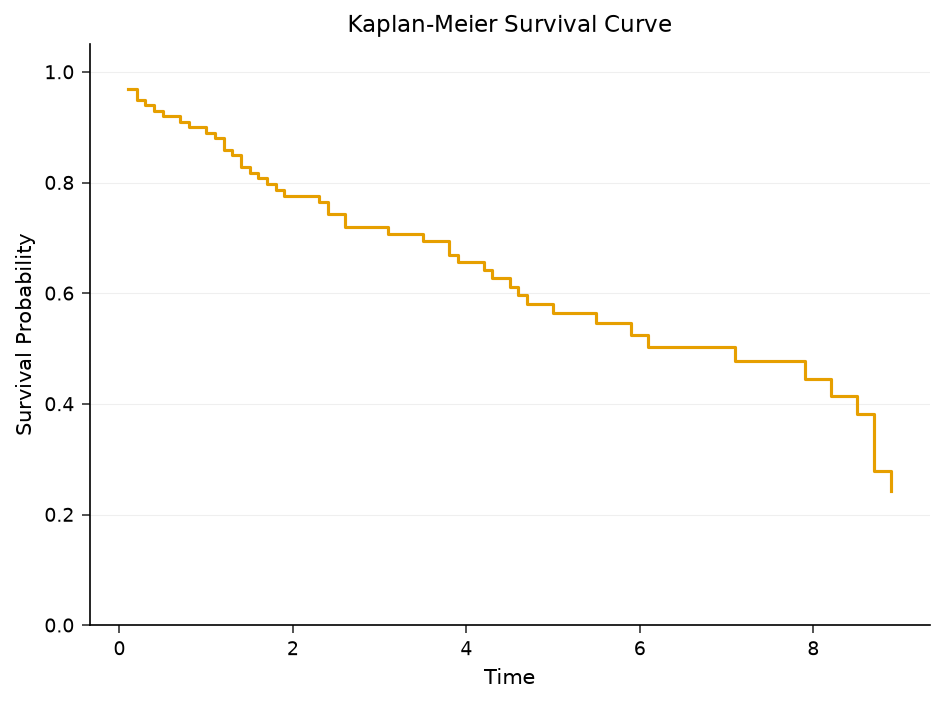

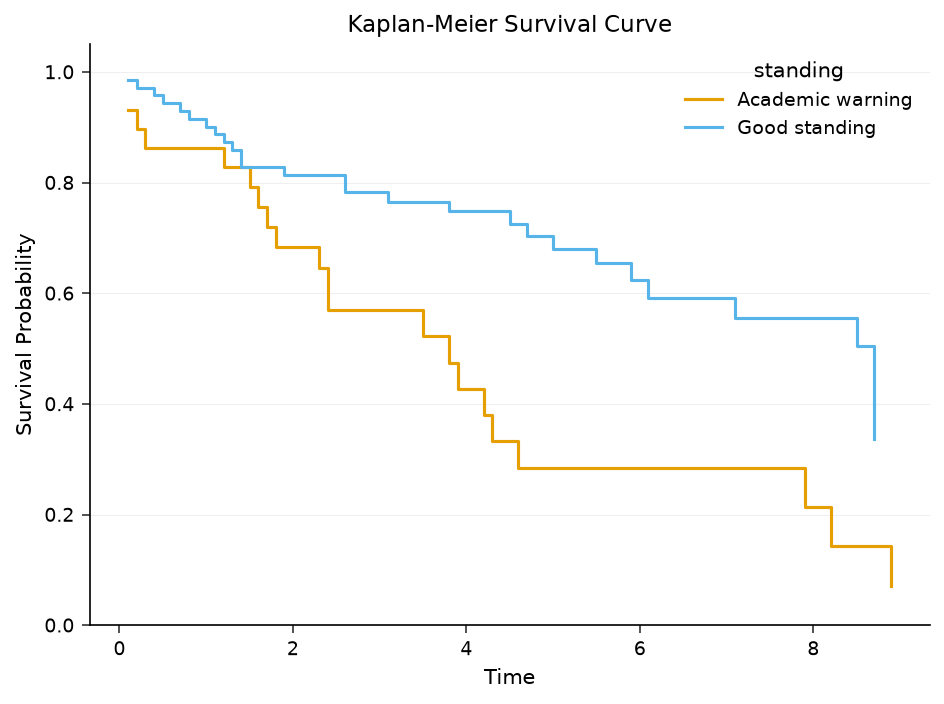

In [5]:
proc lifetest data=enrollments plots=survival method=km;
    time time_terms*dropped(0);
    strata standing / test=(logrank wilcoxon);
run;

## 6. Multivariable Cox proportional-hazards model for dropout

**PROC PHREG** fits the **Cox proportional-hazards** model for the dropout hazard, adjusting the predictors simultaneously. Key requests:

- `dropped(0)` makes **dropout** the event and everything else censored.
- `CLASS first_gen_lbl (ref="Continuing-gen") / param=ref` reference-codes the first-generation factor so its hazard ratio is read against continuing-generation students.
- `TIES=EFRON` is the recommended tie-handling approximation when several students leave in the same term.
- `RL` adds hazard-ratio (risk-limit) confidence intervals.
- The `HAZARDRATIO` statement requests the first-generation contrast against the reference group; the resulting hazard ratio appears in the Analysis of Maximum Likelihood Estimates table below.

A hazard ratio above 1 means *faster* dropout (higher risk); below 1 means *slower* dropout (protective).

In [6]:
proc phreg data=enrollments;
    class first_gen_lbl (ref="Continuing-gen") / param=ref;
    model time_terms*dropped(0) = hs_gpa term1_gpa first_gen_lbl pell
          / ties=efron rl;
    hazardratio "First-generation vs continuing" first_gen_lbl / diff=ref;
run;

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 49
-2 LOG L                    352.536
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     30.2868         4      <.0001
Wald                 29.9969         4      <.0001
Score (Log-Rank)     31.4678         4      <.0001

                                     Analysis of Maximum Likelihood Estimates                                      

Parameter            DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
-------------  --------  --------  --------------  ----------  ----------  ------------  ------------  ------------
HS_GPA                1  -0.81037         0.36729    

NOTE: PROC PHREG data=enrollments

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using R wrapper


## 7. Interpretation and next steps

**Reading the output, end to end:**

- **PROC MEANS** confirms the simulated signal: students who graduated carry a higher first-term GPA (2.94 vs 2.54) and high-school GPA (3.10 vs 2.90) than students who dropped, and the still-enrolled students sit at the 12-term ceiling — the right-censoring the survival models respect.
- **PROC FREQ** shows that the first-term academic-warning flag tracks the outcome (21 of 29 flagged students dropped; 41 of 71 good-standing students graduated; *p* = 0.0100), while honestly flagging that the chi-square is fragile in a 100-student table with sparse cells.
- **PROC UNIVARIATE** shows that *conditional on dropping*, both groups leave early (median ~2.4–2.6 terms); the standing effect is about how many students drop and how fast the at-risk pool thins, not the timing among those who leave.
- **PROC LIFETEST** delivers the headline: Kaplan-Meier dropout curves that separate sharply by standing (median 3.8 vs 8.7 terms; log-rank *p* = 0.0011, Wilcoxon *p* = 0.0056). The early-alert flag is a genuine, statistically supported discriminator of dropout timing.
- **PROC PHREG** quantifies each predictor's adjusted effect on the dropout hazard. After adjustment, **first-term GPA is the strongest protective factor** (hazard ratio 0.21 per GPA point, 95% CI 0.10–0.44, *p* < 0.0001): each additional GPA point cuts the dropout hazard by roughly four-fifths. **High-school GPA** is also protective (HR 0.45, 95% CI 0.22–0.91, *p* = 0.027). **First-generation students** face about double the dropout hazard of continuing-generation peers with the same GPAs (HR 2.03, 95% CI 1.07–3.84, *p* = 0.031). **Pell status is not significant** once GPA is controlled (HR 0.95, 95% CI 0.53–1.69, *p* = 0.85) — a useful reminder that a raw risk factor can wash out after adjustment. The global null is decisively rejected (likelihood-ratio chi-square = 30.29 on 4 df, *p* < 0.0001).

**How an institution would act on this.** The Cox model produces a per-student linear predictor (risk score) that rank-orders the cohort by dropout hazard; the highest-risk students — low first-term GPA combined with first-generation status — are routed to early-alert advising in their first terms, when intervention is cheapest and most effective. The Kaplan-Meier comparison gives advisers a single, defensible criterion they already collect at the end of term one: academic standing.

**Caveats and extensions.** (1) This synthetic cohort treats graduation as censoring for the dropout model; with real data, graduation and dropout are genuine **competing risks**, and a competing-risks (cumulative-incidence) extension via PROC PHREG `EVENTCODE=` would avoid over-stating the dropout probability. (2) The proportional-hazards assumption should be checked (PHREG `ASSESS PH` or Schoenfeld residuals) before trusting a single hazard ratio across all terms. (3) Time-varying covariates — term-by-term GPA, financial-aid changes, course load — are common in retention data and are naturally handled by PHREG programming statements. (4) The 100-student cohort here is intentionally compact so the example is fully self-contained and quick to reproduce; a production analysis would carry several thousand students, tightening every confidence interval. Always validate a deployed risk score on a held-out cohort before acting on it operationally.